# Brain Stroke Prediction - Exploratory Data Analysis (EDA)

This project focuses on analysing a stroke prediction dataset to identify patterns and risk factors associated with stroke occurrence.

**Dataset Source:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

## Data Dictionary

- id - Unique identifier for each patient - Not useful for modelling  
- gender - Patient's gender - Male, Female, Other  
- age - Age of the patient - Continuous numerical  
- hypertension - Whether patient has hypertension - 0 = No, 1 = Yes  
- heart_disease - Whether patient has heart disease - 0 = No, 1 = Yes  
- ever_married - Marital status - Yes, No  
- work_type - Type of employment - children, Govt_job, Never_worked, Private, Self-employed  
- Residence_type - Type of residence - Urban, Rural  
- avg_glucose_level - Average glucose level in blood - Continuous numerical  
- bmi - Body Mass Index - Contains missing values  
- smoking_status - Smoking history - formerly smoked, never smoked, smokes, Unknown (missing info)  
- stroke - Stroke occurrence (target variable) - 0 = No, 1 = Yes  

## Importing Libraries

For the EDA We imported Pandas and NumPy for data handling and then Matplotlib and Seaborn for data visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
pd.set_option('display.max_columns',None)

In [7]:
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
#Loading the dataset

In [4]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,9046,51676,31112,60182,1665,56669,53882,10434,27419,60491
gender,Male,Female,Male,Female,Female,Male,Male,Female,Female,Female
age,67.0,61.0,80.0,49.0,79.0,81.0,74.0,69.0,59.0,78.0
hypertension,0,0,0,0,1,0,1,0,0,0
heart_disease,1,0,1,0,0,0,1,0,0,0
ever_married,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
work_type,Private,Self-employed,Private,Private,Self-employed,Private,Private,Private,Private,Private
Residence_type,Urban,Rural,Rural,Urban,Rural,Urban,Rural,Urban,Rural,Urban
avg_glucose_level,228.69,202.21,105.92,171.23,174.12,186.21,70.09,94.39,76.15,58.57
bmi,36.6,NaN,32.5,34.4,24.0,29.0,27.4,22.8,NaN,24.2


## Initial Data Exploration

In the next cells, we’ll look at the number of rows and columns, the data types of each feature, and whether there are any missing values.

In [9]:
df.shape
#Checks how many rows and columns we have

(5110, 12)

In [10]:
df.info()
#The info() method prints information about the DataFrame.
#The information contains the number of columns, column labels, column data types, memory usage, range index, and the number of cells in each column (non-null values).

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [11]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Observations (Initial Data Exploration)

- The dataset has 5110 rows and 12 columns.

- Most of the features do not have missing values, except for the bmi column, which has some missing entries.

- The dataset contains a mix of data types:
  - Numerical features (like age, bmi, glucose levels)
  - Categorical features (like gender, work type, smoking status)
  - Binary features (like hypertension, heart disease, stroke)

- The target variable stroke is binary (0 = no stroke, 1 = stroke).

- From the summary statistics, we can see that:
  - The average age is around 43 years
  - The average glucose level is around 106
  - BMI varies quite a bit and includes missing values

- The stroke column looks highly imbalanced, with most values being 0 (no stroke).

In [13]:
df.isnull().sum()
# Checks how many null values each column has

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Missing Values

- All columns have no missing values except bmi 
- bmi has 201 missing values  
- We should not drop these rows because the dataset is already imbalanced  
- We will handle this later using imputation (Imputation means filling in missing values instead of removing them.)

## Target Variable Analysis

Here we check how the stroke values are distributed in the dataset.

In [14]:
# Shows the count of each class (how many 0s and 1s we have)
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [15]:
# Shows the proportion/percentage of each class
df['stroke'].value_counts(normalize=True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

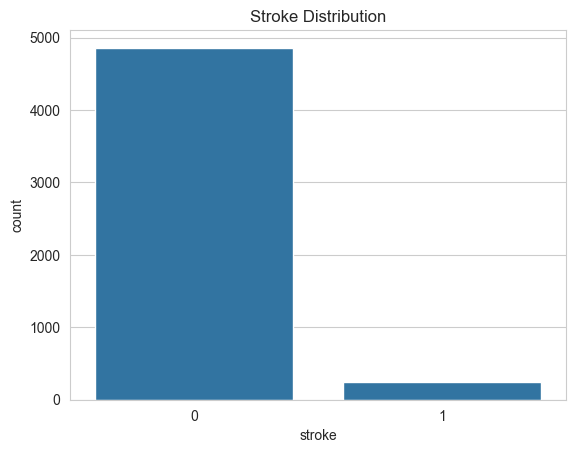

In [16]:
# Visualizes the distribution of stroke values
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

### Observations

- Most of the data is class 0 (no stroke), few cases are class 1 (stroke)  
- About 95% of the data is no stroke and only about 5% is stroke  
- This shows that the dataset is highly imbalanced  
- This will need to be handled later during preprocessing  

## Age Distribution

Here, we look at how age is distributed in the dataset.
How the ages are spread out.
If most patients are young, middle-aged, or old.
Any skew (more older or younger people).

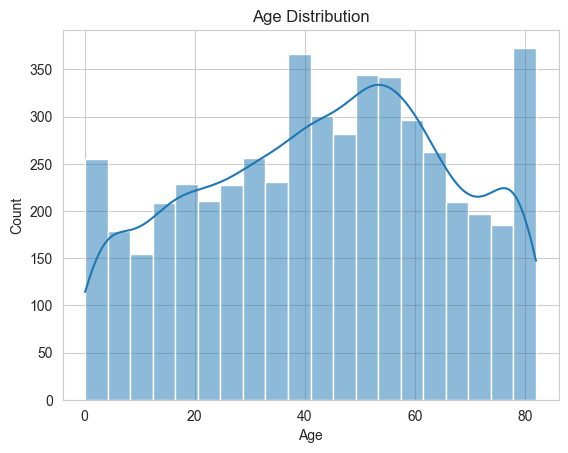

In [17]:
# Plots the distribution of age
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Observations

- Most patients are between ages 30 and 60  
- Peak is around 40–60  
- Very few patients are extremely young or very old  

## Glucose Level Distribution

Here we look at how the average glucose levels are distributed.

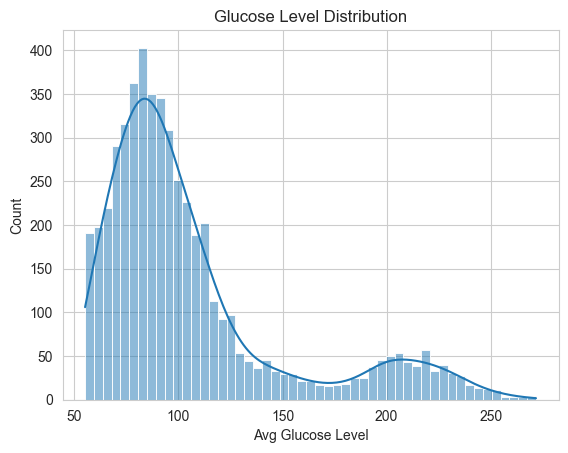

In [18]:
# Plots the distribution of average glucose levels
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title("Glucose Level Distribution")
plt.xlabel("Avg Glucose Level")
plt.ylabel("Count")
plt.show()

### Observations

- Most glucose levels are between 70 and 120  
- There is a clear peak around 80–100  
- The distribution is right-skewed
- There are some higher glucose values (around 200+) but fewer cases there  

## BMI Distribution

Here we look at how BMI values are distributed.

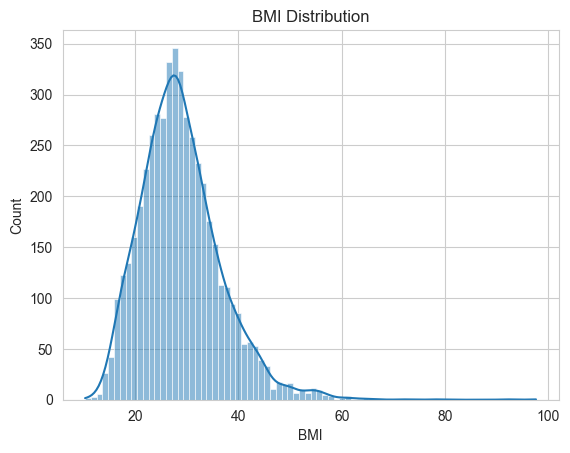

In [19]:
# Plots the distribution of BMI
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

### Observations

- Most BMI values are between 20 and 35  
- The peak is around 25–30  
- The distribution is slightly right-skewed  
- There are a few higher BMI values (above 50) but very few  

## Gender Distribution

Here we look at how gender is distributed in the dataset.

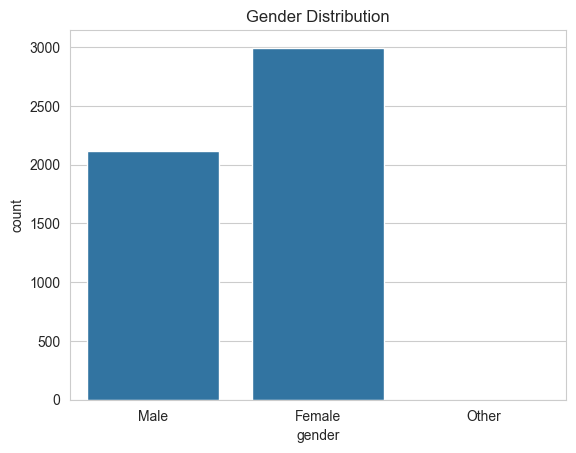

In [20]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

## Work Type Distribution

Here we look at how work types are distributed.

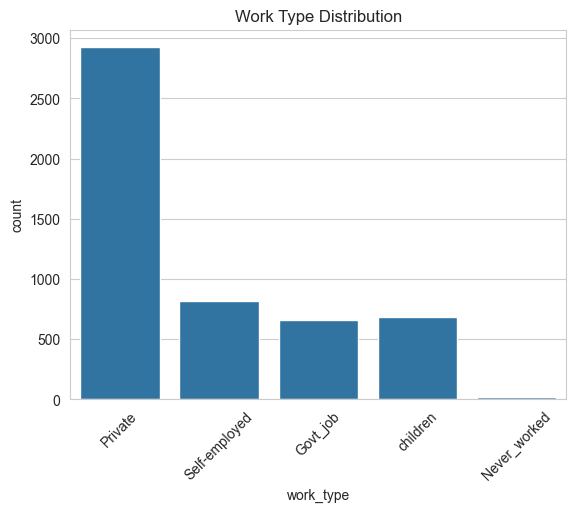

In [21]:
sns.countplot(x='work_type', data=df)
plt.title("Work Type Distribution")
plt.xticks(rotation=45)
plt.show()

### Observations

- Most people work in the private sector  
- Self-employed, Govt_job, and children categories have fewer records  
- "Never_worked" has very few cases  

## Smoking Status Distribution

Here we look at how smoking status is distributed.

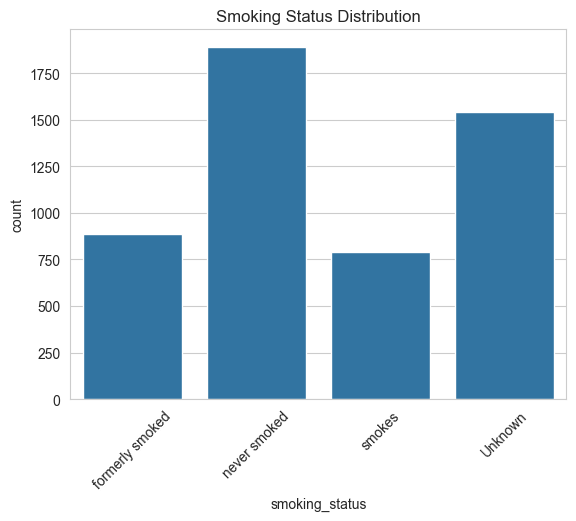

In [22]:
# Shows how smoking status is distributed
sns.countplot(x='smoking_status', data=df)
plt.title("Smoking Status Distribution")
plt.xticks(rotation=45)
plt.show()

## Residence Type Distribution

Here we look at how residence type is distributed.

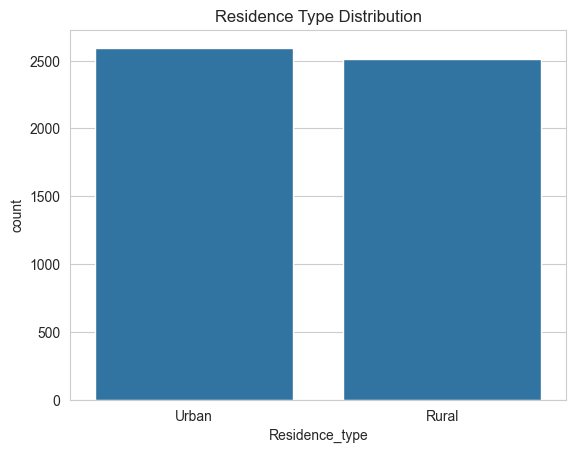

In [23]:
# Shows how residence type is distributed
sns.countplot(x='Residence_type', data=df)
plt.title("Residence Type Distribution")
plt.show()

### Observations

- Urban and rural are almost evenly distributed  

## Age vs Stroke

Here we look at how age differs between stroke and no stroke cases.

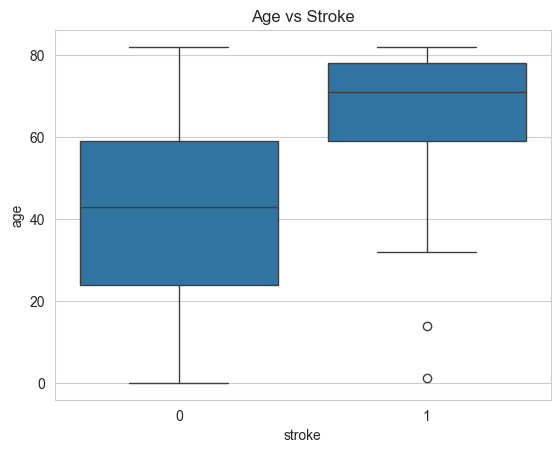

In [24]:
# Shows age distribution for stroke vs no stroke
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.show()

### Observations

- People with stroke are generally older  
- Most stroke cases are around ages 60–80  
- People without stroke are more spread out across ages  
- Note: Age looks like an important factor for stroke (looks like a patient is most likely to get a stroke between the ages of 60 and 80.

## Glucose Level vs Stroke

Here we look at how glucose levels differ between stroke and no stroke cases.

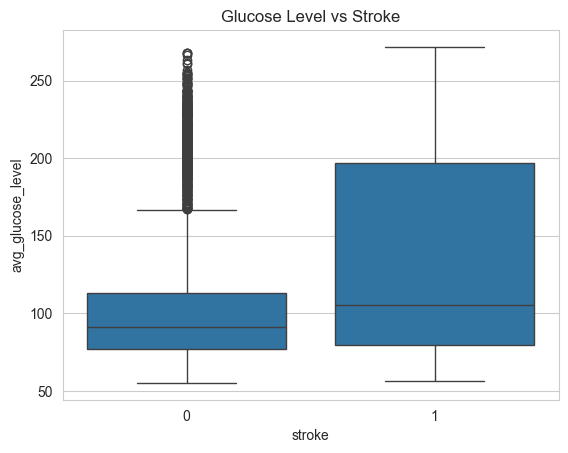

In [25]:
# Shows glucose levels for stroke vs no stroke
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title("Glucose Level vs Stroke")
plt.show()

### Observations

- People with stroke tend to have higher glucose levels  
- The stroke group has a wider spread of values  
- There are more high glucose values in the stroke group  
- Glucose might be a contributing factor but the difference is not as clear as age  

## BMI vs Stroke

Here we look at how BMI differs between stroke and no stroke cases.

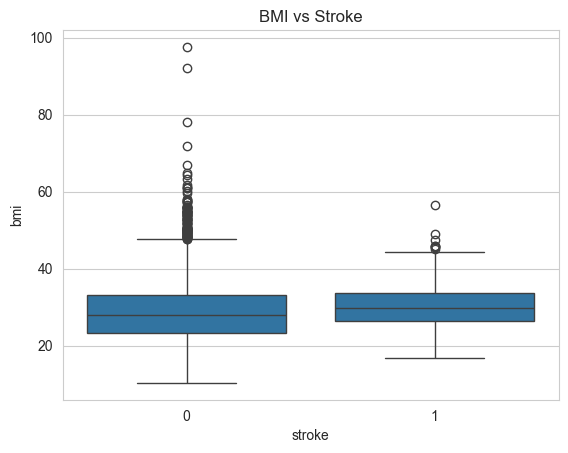

In [26]:
# Shows BMI distribution for stroke vs no stroke
sns.boxplot(x='stroke', y='bmi', data=df)
plt.title("BMI vs Stroke")
plt.show()

### Observations

- BMI is slightly higher for stroke cases  
- Most values are in a similar range for both groups  
- There are some outliers, mostly in the no-stroke group  
- BMI does not show a big difference between the two groups  

## Key Findings

- The dataset is highly imbalanced (very few stroke cases)  
- Stroke cases are mostly in older patients  
- Glucose levels are slightly higher for stroke cases  
- BMI does not show a big difference  
- Most people never smoked, but "Unknown" is quite high  
- BMI has missing values that need to be handled  

## Correlation Heatmap

Here we look at the correlation between numerical features.

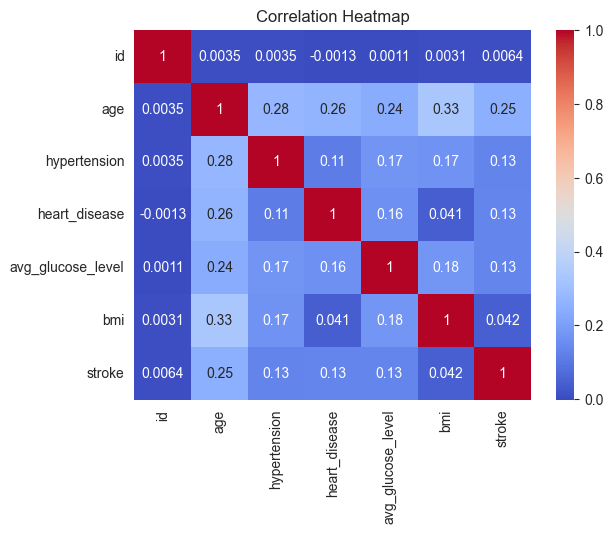

In [27]:
# Shows correlation between numerical features
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observations

- Most features have very low correlation  
- There are no strong relationships between variables  
- Age has the highest correlation with stroke, but still not very strong  
- Overall, the features are not strongly related  